<a href="https://colab.research.google.com/github/KaviduR320/Statistical-Learning-e23306/blob/main/Assignment%207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kalman Filter: Analytical Derivation

## 1. Prior State Distribution

**Given:**
- $x_{k-1}^+ \sim \mathcal{N}(m_{k-1}, P_{k-1})$
- $w_{k-1} \sim \mathcal{N}(0, \Sigma_p)$ (process noise, independent of $x_{k-1}^+$)

**State Prediction:**
$$x_k^- = A_{k-1} x_{k-1}^+ + G_{k-1} w_{k-1}$$

**Mean Calculation:**
$$\mathbb{E}[x_k^-] = A_{k-1} \mathbb{E}[x_{k-1}^+] + G_{k-1} \mathbb{E}[w_{k-1}] = A_{k-1} m_{k-1} \triangleq m_k^-$$

**Covariance Calculation:**
$$\text{Cov}(x_k^-) = A_{k-1} \text{Cov}(x_{k-1}^+) A_{k-1}^\top + G_{k-1} \text{Cov}(w_{k-1}) G_{k-1}^\top$$
$$= A_{k-1} P_{k-1} A_{k-1}^\top + G_{k-1} \Sigma_p G_{k-1}^\top \triangleq P_k^-$$

**Result:**
$$x_k^- \sim \mathcal{N}(m_k^-, P_k^-)$$

---

## 2. Predicted Measurement Distribution

**Measurement Prediction:**
$$y_k^- = H_k x_k^- + z_k$$

where $z_k \sim \mathcal{N}(0, \Sigma_m)$ (measurement noise, independent of $x_k^-$)

**Mean:**
$$\mathbb{E}[y_k^-] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$$

**Covariance:**
$$\text{Cov}(y_k^-) = H_k \text{Cov}(x_k^-) H_k^\top + \text{Cov}(z_k) = H_k P_k^- H_k^\top + \Sigma_m$$

**Result:**
$$y_k^- \sim \mathcal{N}(H_k m_k^-, H_k P_k^- H_k^\top + \Sigma_m)$$

---

## 3. Joint Distribution

**Joint State-Measurement Vector:**
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} = \begin{bmatrix} I \\ H_k \end{bmatrix} x_k^- + \begin{bmatrix} 0 \\ z_k \end{bmatrix}$$

**Joint Mean:**
$$\boldsymbol{\mu} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$

**Joint Covariance:**
$$\boldsymbol{\Sigma} = \begin{bmatrix} P_k^- & P_k^- H_k^\top \\ H_k P_k^- & H_k P_k^- H_k^\top + \Sigma_m \end{bmatrix}$$

**Cross-Covariance Term:**
$$\text{Cov}(x_k^-, y_k^-) = \text{Cov}(x_k^-, H_k x_k^- + z_k) = \text{Cov}(x_k^-, x_k^-) H_k^\top = P_k^- H_k^\top$$

**Result:**
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathcal{N}\left(\boldsymbol{\mu}, \boldsymbol{\Sigma}\right)$$

---

## 4. Posterior Distribution (Conditional Update)

**Posterior State:**
$$x_k^+ \triangleq (x_k^- \mid y_k^- = y_k^{\text{obs}})$$

**Conditional Gaussian Theorem:** For jointly Gaussian variables:
$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}\right)$$

The conditional distribution is:
$$X \mid Y = y \sim \mathcal{N}\left(\mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y), \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}\right)$$

**Mapping to Our Variables:**
- $X = x_k^-$, $Y = y_k^-$
- $\mu_X = m_k^-$, $\mu_Y = H_k m_k^-$
- $\Sigma_{XX} = P_k^-$, $\Sigma_{XY} = P_k^- H_k^\top$
- $\Sigma_{YX} = H_k P_k^-$, $\Sigma_{YY} = H_k P_k^- H_k^\top + \Sigma_m$

**Kalman Gain Definition:**
$$K_k \triangleq \Sigma_{XY}\Sigma_{YY}^{-1} = P_k^- H_k^\top (H_k P_k^- H_k^\top + \Sigma_m)^{-1}$$

**Posterior Mean:**
$$m_k = m_k^- + K_k (y_k^{\text{obs}} - H_k m_k^-)$$

**Posterior Covariance:**
$$P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k) P_k^-$$

**Result:**
$$x_k^+ \sim \mathcal{N}(m_k, P_k)$$

---

## 5. Conditional Statistics

**Conditional Expectation:**
$$\mathbb{E}[x_k^- \mid y_k^- = y_k^{\text{obs}}] = m_k = m_k^- + K_k (y_k^{\text{obs}} - H_k m_k^-)$$

**Conditional Covariance:**
$$\text{Var}(x_k^- \mid y_k^- = y_k^{\text{obs}}) = P_k = (I - K_k H_k) P_k^-$$

**Kalman Gain (Expanded Form):**
$$K_k = P_k^- H_k^\top (H_k P_k^- H_k^\top + \Sigma_m)^{-1}$$

> **Interpretation:** The conditional expectation $\mathbb{E}[x_k^- \mid y_k^- = y_k^{\text{obs}}]$ represents the minimum mean square error (MMSE) estimate, while the conditional covariance $P_k$ quantifies the estimation uncertainty.

---

## Kalman Filter Algorithm Summary

### Prediction (Time Update)

**State Prediction:**
$$m_k^- = A_{k-1} m_{k-1}$$

**Covariance Prediction:**
$$P_k^- = A_{k-1} P_{k-1} A_{k-1}^\top + G_{k-1} \Sigma_p G_{k-1}^\top$$

### Update (Measurement Update)

**Kalman Gain Computation:**
$$K_k = P_k^- H_k^\top (H_k P_k^- H_k^\top + \Sigma_m)^{-1}$$

**State Correction:**
$$m_k = m_k^- + K_k (y_k^{\text{obs}} - H_k m_k^-)$$

**Covariance Correction:**
$$P_k = (I - K_k H_k) P_k^-$$

### Algorithm Flow


# Scalar Kalman Filter: A Comprehensive Analysis

## 1. Prediction Phase (Prior Distribution)

**System Model:** For the univariate case, we have:
$$x_k^- = a x_{k-1}^+ + w_{k-1}, \quad w_{k-1} \sim \mathcal{N}(0, q)$$

**Prior Mean:**
$$\mu_k^- = \mathbb{E}[x_k^-] = a\mathbb{E}[x_{k-1}^+] + \mathbb{E}[w_{k-1}] = a\mu_{k-1}$$

**Prior Variance:**
$$\sigma_k^{-2} = \text{Var}(x_k^-) = a^2\text{Var}(x_{k-1}^+) + \text{Var}(w_{k-1}) = a^2\sigma_{k-1}^2 + q$$

**Compact Form:**
$$\boxed{\mu_k^- = a\mu_{k-1}, \quad \sigma_k^{-2} = a^2\sigma_{k-1}^2 + q}$$

---

## 2. Update Phase (Posterior Distribution)

**Measurement Model:**
$$y_k = h x_k^- + z_k, \quad z_k \sim \mathcal{N}(0, r)$$

**Innovation (Measurement Residual):**
$$e_k = y_k^{\text{obs}} - h\mu_k^-$$

**Innovation Variance:**
$$s_k^2 = h^2\sigma_k^{-2} + r$$

**Kalman Gain (Optimal Weighting):**
$$\mathcal{K}_k = \frac{\sigma_k^{-2} h}{s_k^2} = \frac{\sigma_k^{-2} h}{h^2\sigma_k^{-2} + r}$$

**Posterior Mean:**
$$\mu_k = \mu_k^- + \mathcal{K}_k e_k = \mu_k^- + \frac{\sigma_k^{-2} h}{h^2\sigma_k^{-2} + r}(y_k^{\text{obs}} - h\mu_k^-)$$

**Posterior Variance:**
$$\sigma_k^2 = (1 - \mathcal{K}_k h)\sigma_k^{-2} = \left(1 - \frac{\sigma_k^{-2} h^2}{h^2\sigma_k^{-2} + r}\right)\sigma_k^{-2}$$

**Alternative Form:**
$$\boxed{\sigma_k^2 = \frac{\sigma_k^{-2} r}{h^2\sigma_k^{-2} + r}}$$

---

## 3. Predictive Measurement Distribution

**Before Observation:** The distribution of the predicted measurement is:
$$p(y_k \mid Y_{k-1}) = \mathcal{N}(h\mu_k^-, h^2\sigma_k^{-2} + r)$$

**Justification:**
- **Expectation:** $\mathbb{E}[y_k \mid Y_{k-1}] = h\mathbb{E}[x_k^- \mid Y_{k-1}] + \mathbb{E}[z_k] = h\mu_k^-$
- **Variance:** $\text{Var}(y_k \mid Y_{k-1}) = h^2\text{Var}(x_k^- \mid Y_{k-1}) + \text{Var}(z_k) = h^2\sigma_k^{-2} + r$

---

## 4. Posterior-Predictive Measurement Distribution

**After Observation:** The distribution conditioned on all data up to time k:
$$p(y_k \mid Y_k) = \mathcal{N}(h\mu_k, h^2\sigma_k^2 + r)$$

**Derivation:** Using the updated state distribution $x_k^+ \sim \mathcal{N}(\mu_k, \sigma_k^2)$:
- **Mean:** $\mathbb{E}[y_k \mid Y_k] = h\mathbb{E}[x_k^+ \mid Y_k] + \mathbb{E}[z_k] = h\mu_k$
- **Variance:** $\text{Var}(y_k \mid Y_k) = h^2\text{Var}(x_k^+ \mid Y_k) + \text{Var}(z_k) = h^2\sigma_k^2 + r$

---



KALMAN FILTER PARAMETERS
State Transition (a): 0.85
Process Noise (q):    0.8
Measurement Gain (h): 0.75
Measurement Noise (r): 0.4
Initial Mean (m0):    2.0
Initial Variance (P0): 4.0


/tmp/ipykernel_13082/3567446835.py:202: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  display(HTML(anim.to_html5_video()))
/tmp/ipykernel_13082/3567446835.py:202: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  display(HTML(anim.to_html5_video()))
/tmp/ipykernel_13082/3567446835.py:202: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  display(HTML(anim.to_html5_video()))
/tmp/ipykernel_13082/3567446835.py:202: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  display(HTML(anim.to_html5_video()))
/tmp/ipykernel_13082/3567446835.py:202: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  display(HTML(anim.to_html5_video()))


/tmp/ipykernel_13082/3567446835.py:318: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13082/3567446835.py:318: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13082/3567446835.py:318: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


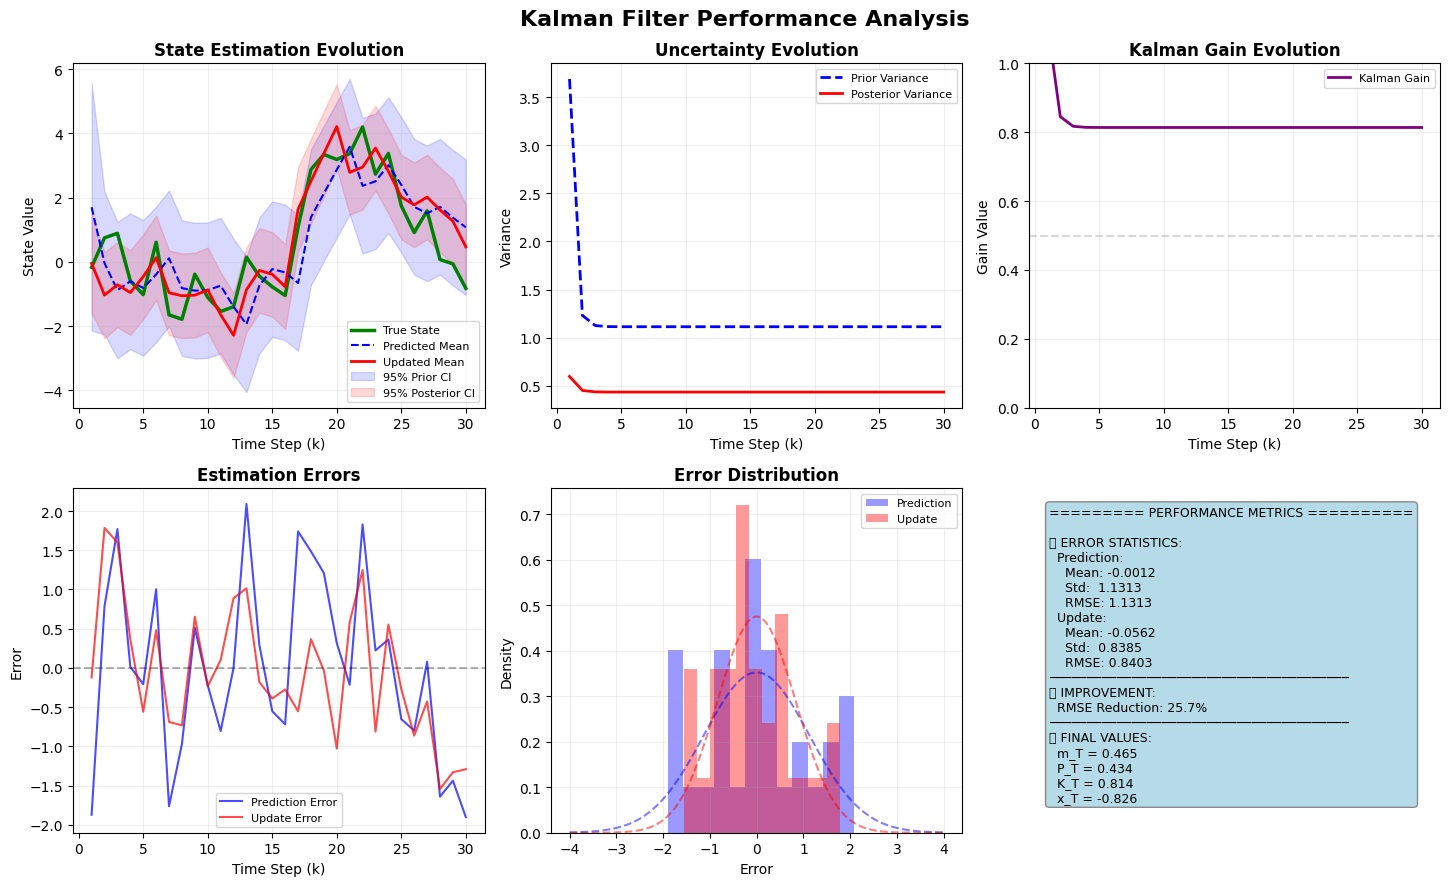


KALMAN FILTER SUMMARY
Final State Estimate:     μ_T = 0.4651
Final State Uncertainty:  σ²_T = 0.4340
Final Kalman Gain:        K_T = 0.8137
Final True State:         x_T = -0.8261
------------------------------------------------------------
RMSE (Prediction):        1.1313
RMSE (Update):            0.8403
Improvement:              25.7%

STEADY-STATE ANALYSIS
Theoretical Steady-State Gain: 0.8137
Actual Final Gain:              0.8137
Difference:                     0.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML
import matplotlib.patches as mpatches

# ============================================================
# PARAMETER CONFIGURATION
# ============================================================
a = 0.85        # State transition coefficient
q = 0.8         # Process noise variance
h = 0.75        # Measurement sensitivity
r = 0.4         # Measurement noise variance
m0 = 2.0        # Initial mean
P0 = 4.0        # Initial covariance
T = 30          # Number of time steps

print("="*60)
print("KALMAN FILTER PARAMETERS")
print("="*60)
print(f"State Transition (a): {a}")
print(f"Process Noise (q):    {q}")
print(f"Measurement Gain (h): {h}")
print(f"Measurement Noise (r): {r}")
print(f"Initial Mean (m0):    {m0}")
print(f"Initial Variance (P0): {P0}")
print("="*60)

# ============================================================
# SYNTHETIC DATA GENERATION
# ============================================================
np.random.seed(123)
x_true = np.zeros(T)
y_obs = np.zeros(T)

# Generate true states
x_true[0] = m0 + np.sqrt(P0) * np.random.randn()
for k in range(1, T):
    x_true[k] = a * x_true[k-1] + np.sqrt(q) * np.random.randn()

# Generate noisy measurements
for k in range(T):
    y_obs[k] = h * x_true[k] + np.sqrt(r) * np.random.randn()

# ============================================================
# KALMAN FILTER IMPLEMENTATION
# ============================================================
m_pred = np.zeros(T)      # Predicted mean
P_pred = np.zeros(T)      # Predicted variance
m_upd = np.zeros(T)       # Updated mean
P_upd = np.zeros(T)       # Updated variance
K_gain = np.zeros(T)      # Kalman gain

# Initialize
m_upd[0] = m0
P_upd[0] = P0

for k in range(T):
    # --- Prediction ---
    if k == 0:
        m_pred[k] = a * m0
        P_pred[k] = a**2 * P0 + q
    else:
        m_pred[k] = a * m_upd[k-1]
        P_pred[k] = a**2 * P_upd[k-1] + q

    # --- Update ---
    S_k = h**2 * P_pred[k] + r
    K_gain[k] = P_pred[k] * h / S_k
    m_upd[k] = m_pred[k] + K_gain[k] * (y_obs[k] - h * m_pred[k])
    P_upd[k] = (1 - K_gain[k] * h) * P_pred[k]

# ============================================================
# ENHANCED ANIMATION
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Kalman Filter: Sequential Bayesian Estimation',
             fontsize=16, fontweight='bold')

x_range = np.linspace(-10, 15, 500)

def animate(frame):
    # Clear all subplots
    for ax in axes.flat:
        ax.clear()

    # --- Subplot 1: Prior Distribution ---
    ax1 = axes[0, 0]
    prior_pdf = norm.pdf(x_range, m_pred[frame], np.sqrt(P_pred[frame]))
    ax1.plot(x_range, prior_pdf, 'b-', lw=2.5, label='Prior')
    ax1.axvline(x_true[frame], color='green', ls='--', lw=2,
                label='True State', alpha=0.8)
    ax1.axvline(m_pred[frame], color='blue', ls=':', lw=2, alpha=0.6)
    ax1.fill_between(x_range, 0, prior_pdf, alpha=0.15, color='blue')
    ax1.set_xlabel('State Value (x)', fontsize=10)
    ax1.set_ylabel('Density', fontsize=10)
    ax1.set_title(f'Prior Distribution (k={frame+1})', fontweight='bold')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.2)

    # --- Subplot 2: Posterior Distribution ---
    ax2 = axes[0, 1]
    post_pdf = norm.pdf(x_range, m_upd[frame], np.sqrt(P_upd[frame]))
    ax2.plot(x_range, post_pdf, 'r-', lw=2.5, label='Posterior')
    ax2.axvline(x_true[frame], color='green', ls='--', lw=2,
                label='True State', alpha=0.8)
    ax2.axvline(m_upd[frame], color='red', ls=':', lw=2, alpha=0.6)
    ax2.fill_between(x_range, 0, post_pdf, alpha=0.15, color='red')
    ax2.set_xlabel('State Value (x)', fontsize=10)
    ax2.set_ylabel('Density', fontsize=10)
    ax2.set_title(f'Posterior Distribution (k={frame+1})', fontweight='bold')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.2)

    # --- Subplot 3: Prior vs Posterior Comparison ---
    ax3 = axes[0, 2]
    ax3.plot(x_range, prior_pdf, 'b-', lw=2, alpha=0.6, label='Prior')
    ax3.plot(x_range, post_pdf, 'r-', lw=2, alpha=0.6, label='Posterior')
    ax3.axvline(x_true[frame], color='green', ls='--', lw=2, alpha=0.8)
    ax3.axvline(m_pred[frame], color='blue', ls=':', alpha=0.5)
    ax3.axvline(m_upd[frame], color='red', ls=':', alpha=0.5)
    ax3.fill_between(x_range, 0, prior_pdf, color='blue', alpha=0.08)
    ax3.fill_between(x_range, 0, post_pdf, color='red', alpha=0.08)
    ax3.set_xlabel('State Value (x)', fontsize=10)
    ax3.set_ylabel('Density', fontsize=10)
    ax3.set_title('Prior vs Posterior', fontweight='bold')
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(True, alpha=0.2)

    # --- Subplot 4: Measurement Space ---
    ax4 = axes[1, 0]
    y_range = np.linspace(-8, 12, 400)
    pred_meas = norm.pdf(y_range, h*m_pred[frame],
                         np.sqrt(h**2*P_pred[frame] + r))
    post_meas = norm.pdf(y_range, h*m_upd[frame],
                         np.sqrt(h**2*P_upd[frame] + r))
    ax4.plot(y_range, pred_meas, 'b-', lw=2, alpha=0.6,
             label='Predicted Measurement')
    ax4.plot(y_range, post_meas, 'r-', lw=2, alpha=0.6,
             label='Posterior Measurement')
    ax4.axvline(y_obs[frame], color='orange', lw=2.5,
                label='Observed')
    ax4.axvline(h*m_pred[frame], color='blue', ls=':', alpha=0.5)
    ax4.axvline(h*m_upd[frame], color='red', ls=':', alpha=0.5)
    ax4.set_xlabel('Measurement Value (y)', fontsize=10)
    ax4.set_ylabel('Density', fontsize=10)
    ax4.set_title('Measurement Predictions', fontweight='bold')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.grid(True, alpha=0.2)

    # --- Subplot 5: Kalman Gain & Uncertainty ---
    ax5 = axes[1, 1]
    # Bar plot for Kalman gain
    ax5.bar(['Kalman\nGain'], [K_gain[frame]], color='purple',
            alpha=0.6, width=0.4)
    ax5.axhline(y=0.5, color='gray', ls='--', alpha=0.3)
    ax5.set_ylabel('Gain Value', fontsize=10)
    ax5.set_title(f'Kalman Gain: {K_gain[frame]:.3f}', fontweight='bold')
    ax5.set_ylim([0, 1])
    ax5.grid(True, alpha=0.2, axis='y')

    # --- Subplot 6: Information Summary ---
    ax6 = axes[1, 2]
    ax6.axis('off')

    # Compute innovation
    innovation = y_obs[frame] - h * m_pred[frame]
    S_k = h**2 * P_pred[frame] + r

    info_text = (
        f"⏱ Time: {frame+1}/{T}\n"
        f"{'─'*30}\n"
        f"📊 PRIOR:\n"
        f"  μ⁻ = {m_pred[frame]:.3f}\n"
        f"  σ²⁻ = {P_pred[frame]:.3f}\n"
        f"  σ⁻  = {np.sqrt(P_pred[frame]):.3f}\n"
        f"{'─'*30}\n"
        f"📈 POSTERIOR:\n"
        f"  μ⁺ = {m_upd[frame]:.3f}\n"
        f"  σ²⁺ = {P_upd[frame]:.3f}\n"
        f"  σ⁺  = {np.sqrt(P_upd[frame]):.3f}\n"
        f"{'─'*30}\n"
        f"📏 MEASUREMENT:\n"
        f"  y_obs  = {y_obs[frame]:.3f}\n"
        f"  y_pred = {h*m_pred[frame]:.3f}\n"
        f"  innov  = {innovation:.3f}\n"
        f"  S      = {S_k:.3f}\n"
        f"{'─'*30}\n"
        f"🎯 GAIN: {K_gain[frame]:.3f}"
    )
    ax6.text(0.05, 0.95, info_text, transform=ax6.transAxes,
             verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.9))

    plt.tight_layout()

# Create and display animation
anim = FuncAnimation(fig, animate, frames=T, interval=400, repeat=True)
plt.close()
display(HTML(anim.to_html5_video()))

# ============================================================
# CONVERGENCE AND PERFORMANCE ANALYSIS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Kalman Filter Performance Analysis',
             fontsize=16, fontweight='bold')

time_steps = np.arange(1, T+1)

# --- (1) State Tracking ---
ax1 = axes[0, 0]
ax1.plot(time_steps, x_true, 'g-', lw=2.5, label='True State')
ax1.plot(time_steps, m_pred, 'b--', lw=1.5, label='Predicted Mean')
ax1.plot(time_steps, m_upd, 'r-', lw=2, label='Updated Mean')
ax1.fill_between(time_steps, m_pred - 2*np.sqrt(P_pred),
                  m_pred + 2*np.sqrt(P_pred), color='blue',
                  alpha=0.15, label='95% Prior CI')
ax1.fill_between(time_steps, m_upd - 2*np.sqrt(P_upd),
                  m_upd + 2*np.sqrt(P_upd), color='red',
                  alpha=0.15, label='95% Posterior CI')
ax1.set_xlabel('Time Step (k)', fontsize=10)
ax1.set_ylabel('State Value', fontsize=10)
ax1.set_title('State Estimation Evolution', fontweight='bold')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.2)

# --- (2) Variance Evolution ---
ax2 = axes[0, 1]
ax2.plot(time_steps, P_pred, 'b--', lw=2, label='Prior Variance')
ax2.plot(time_steps, P_upd, 'r-', lw=2, label='Posterior Variance')
ax2.set_xlabel('Time Step (k)', fontsize=10)
ax2.set_ylabel('Variance', fontsize=10)
ax2.set_title('Uncertainty Evolution', fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.2)

# --- (3) Kalman Gain Evolution ---
ax3 = axes[0, 2]
ax3.plot(time_steps, K_gain, 'purple', lw=2, label='Kalman Gain')
ax3.axhline(y=0.5, color='gray', ls='--', alpha=0.3)
ax3.set_xlabel('Time Step (k)', fontsize=10)
ax3.set_ylabel('Gain Value', fontsize=10)
ax3.set_title('Kalman Gain Evolution', fontweight='bold')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.2)
ax3.set_ylim([0, 1])

# --- (4) Estimation Errors ---
ax4 = axes[1, 0]
pred_error = x_true - m_pred
upd_error = x_true - m_upd
ax4.plot(time_steps, pred_error, 'b-', lw=1.5, alpha=0.7,
         label='Prediction Error')
ax4.plot(time_steps, upd_error, 'r-', lw=1.5, alpha=0.7,
         label='Update Error')
ax4.axhline(y=0, color='black', ls='--', alpha=0.3)
ax4.set_xlabel('Time Step (k)', fontsize=10)
ax4.set_ylabel('Error', fontsize=10)
ax4.set_title('Estimation Errors', fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.grid(True, alpha=0.2)

# --- (5) Error Distribution ---
ax5 = axes[1, 1]
ax5.hist(pred_error, bins=12, alpha=0.4, color='blue',
         density=True, label='Prediction')
ax5.hist(upd_error, bins=12, alpha=0.4, color='red',
         density=True, label='Update')
# Overlay Gaussian fits
x_norm = np.linspace(-4, 4, 100)
ax5.plot(x_norm, norm.pdf(x_norm, 0, np.std(pred_error)),
         'b--', alpha=0.5)
ax5.plot(x_norm, norm.pdf(x_norm, 0, np.std(upd_error)),
         'r--', alpha=0.5)
ax5.set_xlabel('Error', fontsize=10)
ax5.set_ylabel('Density', fontsize=10)
ax5.set_title('Error Distribution', fontweight='bold')
ax5.legend(loc='best', fontsize=8)
ax5.grid(True, alpha=0.2)

# --- (6) Performance Metrics ---
ax6 = axes[1, 2]
ax6.axis('off')

rmse_pred = np.sqrt(np.mean(pred_error**2))
rmse_upd = np.sqrt(np.mean(upd_error**2))
improvement = (1 - rmse_upd/rmse_pred) * 100

metrics_text = (
    f"{' PERFORMANCE METRICS ':=^40}\n\n"
    f"📊 ERROR STATISTICS:\n"
    f"  Prediction:\n"
    f"    Mean: {np.mean(pred_error):.4f}\n"
    f"    Std:  {np.std(pred_error):.4f}\n"
    f"    RMSE: {rmse_pred:.4f}\n"
    f"  Update:\n"
    f"    Mean: {np.mean(upd_error):.4f}\n"
    f"    Std:  {np.std(upd_error):.4f}\n"
    f"    RMSE: {rmse_upd:.4f}\n"
    f"{'─'*40}\n"
    f"🎯 IMPROVEMENT:\n"
    f"  RMSE Reduction: {improvement:.1f}%\n"
    f"{'─'*40}\n"
    f"📈 FINAL VALUES:\n"
    f"  m_T = {m_upd[-1]:.3f}\n"
    f"  P_T = {P_upd[-1]:.3f}\n"
    f"  K_T = {K_gain[-1]:.3f}\n"
    f"  x_T = {x_true[-1]:.3f}"
)
ax6.text(0.05, 0.95, metrics_text, transform=ax6.transAxes,
         verticalalignment='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightblue',
                  edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.show()

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\n" + "="*60)
print("KALMAN FILTER SUMMARY")
print("="*60)
print(f"Final State Estimate:     μ_T = {m_upd[-1]:.4f}")
print(f"Final State Uncertainty:  σ²_T = {P_upd[-1]:.4f}")
print(f"Final Kalman Gain:        K_T = {K_gain[-1]:.4f}")
print(f"Final True State:         x_T = {x_true[-1]:.4f}")
print("-"*60)
print(f"RMSE (Prediction):        {rmse_pred:.4f}")
print(f"RMSE (Update):            {rmse_upd:.4f}")
print(f"Improvement:              {improvement:.1f}%")
print("="*60)

# ============================================================
# STEADY-STATE ANALYSIS
# ============================================================
# Compute theoretical steady-state Kalman gain
# Solve Riccati equation for steady-state
P_ss = P0
for _ in range(100):
    P_pred_ss = a**2 * P_ss + q
    K_ss = P_pred_ss * h / (h**2 * P_pred_ss + r)
    P_ss = (1 - K_ss * h) * P_pred_ss

print("\n" + "="*60)
print("STEADY-STATE ANALYSIS")
print("="*60)
print(f"Theoretical Steady-State Gain: {K_ss:.4f}")
print(f"Actual Final Gain:              {K_gain[-1]:.4f}")
print(f"Difference:                     {abs(K_ss - K_gain[-1]):.4f}")
print("="*60)

# 2D Position Estimation with Kalman Filter

## Part A: Analytical Derivation

### State-Space Model

The hidden state at time step k is:
$$x_k = \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}$$

### State Transition Matrix A

For a constant-velocity model, the position update is:
$$p_x(k) = p_x(k-1) + v_x(k-1) \Delta t$$
$$p_y(k) = p_y(k-1) + v_y(k-1) \Delta t$$

The velocity remains constant:
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$

Therefore:
$$x_k = \begin{bmatrix} p_x(k-1) + v_x(k-1)\Delta t \\ p_y(k-1) + v_y(k-1)\Delta t \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix}$$

Thus:
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

### Measurement Matrix H

The measurement consists only of position components:
$$y_k = \begin{bmatrix} p_x^{\text{meas}}(k) \\ p_y^{\text{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}$$

Thus:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

### Process Noise Matrix G

For a constant-velocity model with acceleration noise, the position noise is integrated twice:
$$\Delta p_x = \frac{1}{2} a_x \Delta t^2$$
$$\Delta p_y = \frac{1}{2} a_y \Delta t^2$$
$$\Delta v_x = a_x \Delta t$$
$$\Delta v_y = a_y \Delta t$$

The process noise affects the state as:
$$w_{k-1} = \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$

Therefore:
$$Gw_{k-1} = \begin{bmatrix} \frac{1}{2} \Delta t^2 & 0 \\ 0 & \frac{1}{2} \Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$

Thus:
$$G = \begin{bmatrix} \frac{1}{2} \Delta t^2 & 0 \\ 0 & \frac{1}{2} \Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

---



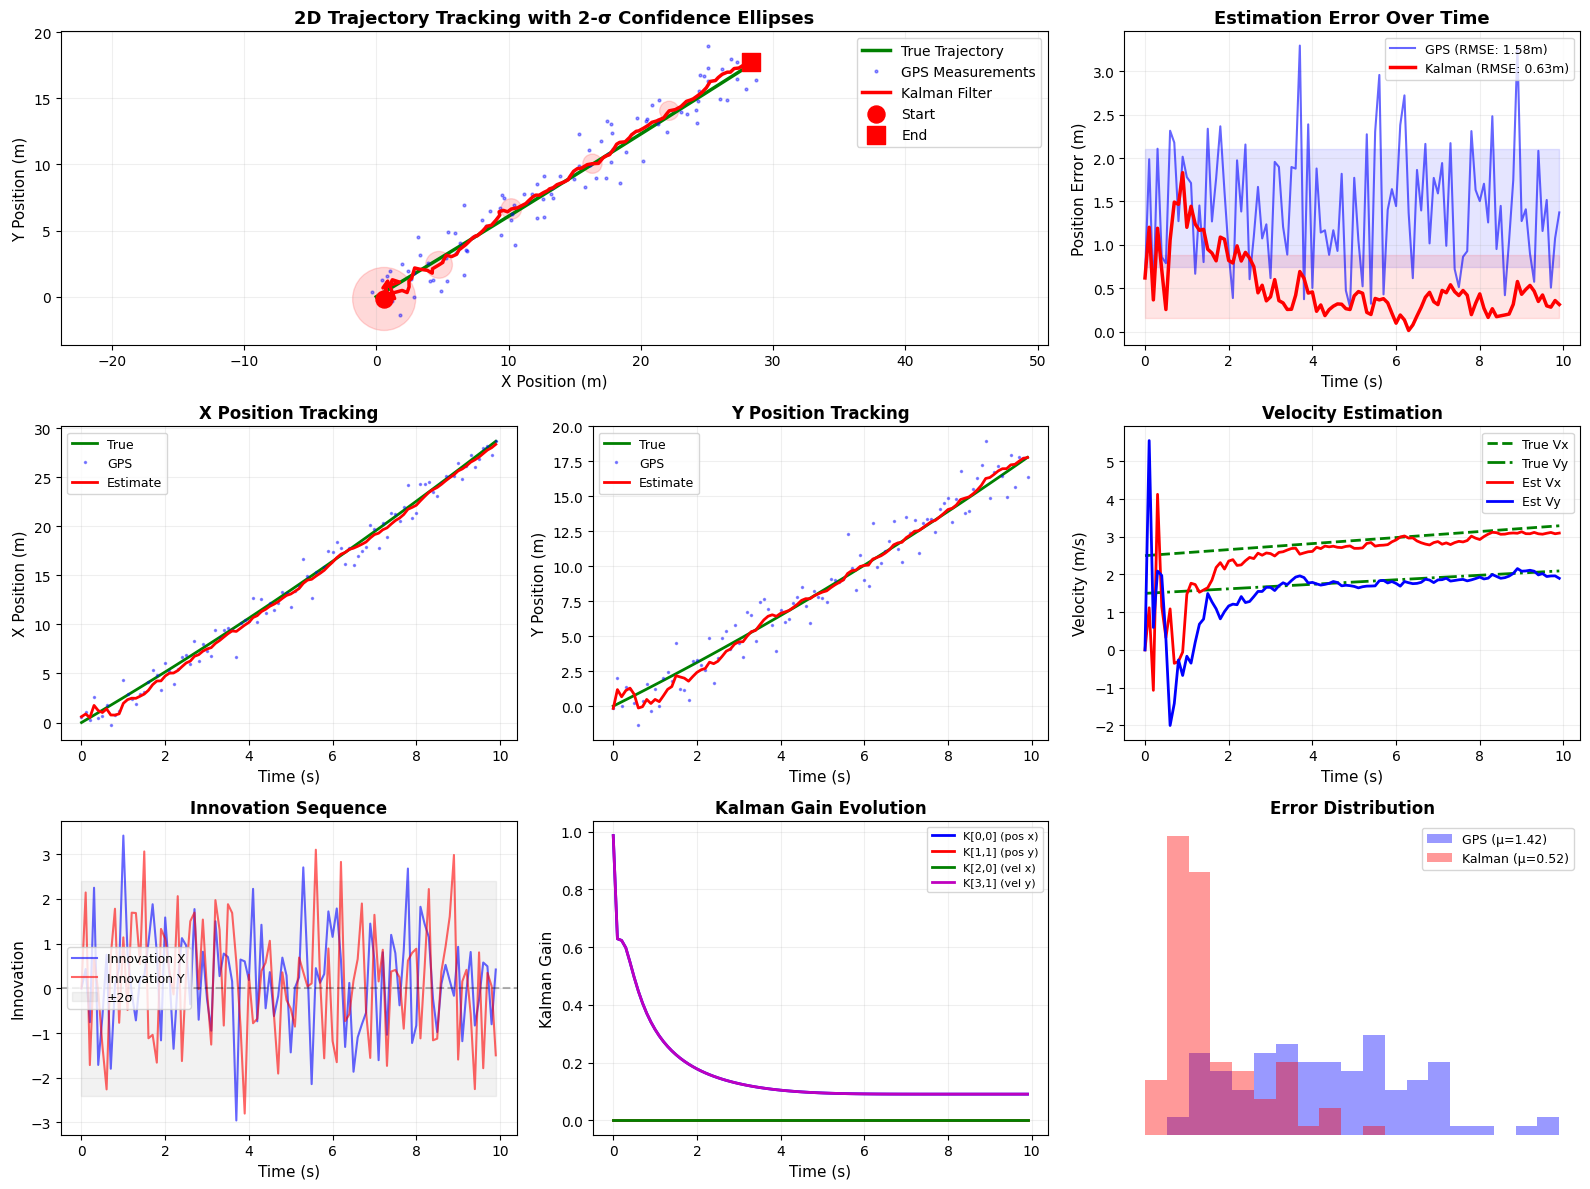


2D KALMAN FILTER - PERFORMANCE SUMMARY
Metric                         GPS             Kalman          Improvement    
----------------------------------------------------------------------
Mean Error (m)                 1.422           0.521                     63.3%
RMSE (m)                       1.578           0.634                     59.8%
Std Dev (m)                    0.683           0.361                     47.2%
----------------------------------------------------------------------
Final Position                 (28.36, 17.78)
Final Velocity                 (3.10, 1.90)
Final Covariance               [0.13, 0.00;
                                0.00, 0.13]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag, sqrtm
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.gridspec as gridspec

# ============================================================
# ENHANCED KALMAN FILTER CLASS
# ============================================================
class KalmanFilter2D:
    """
    Advanced Kalman Filter for 2D position tracking with constant velocity model
    """
    def __init__(self, dt, process_noise_pos, process_noise_vel, measurement_noise):
        """
        Initialize the Kalman Filter

        Parameters:
        dt: time step
        process_noise_pos: position process noise variance
        process_noise_vel: velocity process noise variance
        measurement_noise: measurement noise covariance (2x2 matrix)
        """
        self.dt = dt

        # State transition matrix
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        # Measurement matrix
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process noise matrix
        self.G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        # Process noise covariance
        self.Q = np.array([
            [process_noise_pos, 0],
            [0, process_noise_pos]
        ])

        # Measurement noise covariance
        self.R = measurement_noise

        # Initial state and covariance
        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 100

        # Store history for analysis
        self.history = {'x': [], 'P': [], 'K': [], 'innovation': [], 'S': []}

    def predict(self):
        """Prediction step"""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.G @ self.Q @ self.G.T
        return self.x

    def update(self, z):
        """Update step with measurement z"""
        # Innovation
        innovation = z - self.H @ self.x

        # Innovation covariance
        S = self.H @ self.P @ self.H.T + self.R

        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Update state
        self.x = self.x + K @ innovation

        # Update covariance (Joseph form for numerical stability)
        I = np.eye(4)
        self.P = (I - K @ self.H) @ self.P @ (I - K @ self.H).T + K @ self.R @ K.T

        # Store history
        self.history['x'].append(self.x.copy())
        self.history['P'].append(self.P.copy())
        self.history['K'].append(K.copy())
        self.history['innovation'].append(innovation.flatten())
        self.history['S'].append(S.copy())

        return self.x

    def get_position(self):
        """Get current position estimate"""
        return self.x[0:2].flatten()

    def get_velocity(self):
        """Get current velocity estimate"""
        return self.x[2:4].flatten()

    def get_covariance(self):
        """Get position covariance (2x2)"""
        return self.P[0:2, 0:2]

    def get_innovation(self, k):
        """Get innovation at time k"""
        return self.history['innovation'][k]

    def get_kalman_gain(self, k):
        """Get Kalman gain at time k"""
        return self.history['K'][k]

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def generate_trajectory(T, dt, initial_pos, initial_vel, acceleration):
    """Generate true trajectory with acceleration"""
    true_positions = np.zeros((T, 2))
    true_velocities = np.zeros((T, 2))

    for k in range(T):
        if k == 0:
            true_positions[k] = initial_pos
            true_velocities[k] = initial_vel
        else:
            true_velocities[k] = true_velocities[k-1] + acceleration * dt
            true_positions[k] = true_positions[k-1] + true_velocities[k-1] * dt + 0.5 * acceleration * dt**2

    return true_positions, true_velocities

def confidence_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """Create covariance confidence ellipse"""
    if cov.shape == (2, 2):
        eigvals, eigvecs = np.linalg.eigh(cov)
        order = eigvals.argsort()[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
        width, height = 2 * n_std * np.sqrt(eigvals)
        ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
        ax.add_patch(ellipse)
        return ellipse

def compute_metrics(true, estimated, measurements):
    """Compute performance metrics"""
    error_meas = np.sqrt(np.sum((true - measurements)**2, axis=1))
    error_est = np.sqrt(np.sum((true - estimated)**2, axis=1))

    metrics = {
        'meas_mean': np.mean(error_meas),
        'meas_rmse': np.sqrt(np.mean(error_meas**2)),
        'meas_std': np.std(error_meas),
        'est_mean': np.mean(error_est),
        'est_rmse': np.sqrt(np.mean(error_est**2)),
        'est_std': np.std(error_est),
        'improvement': (1 - np.sqrt(np.mean(error_est**2))/np.sqrt(np.mean(error_meas**2))) * 100
    }
    return metrics, error_meas, error_est

# ============================================================
# SIMULATION SETUP
# ============================================================
np.random.seed(42)
dt = 0.1
T = 100

# Trajectory parameters
initial_position = np.array([0, 0])
initial_velocity = np.array([2.5, 1.5])
acceleration = np.array([0.08, 0.06])

# Generate data
true_positions, true_velocities = generate_trajectory(T, dt, initial_position,
                                                       initial_velocity, acceleration)

# Generate measurements
measurement_noise_std = 1.2
measurements = true_positions + np.random.normal(0, measurement_noise_std, true_positions.shape)

# ============================================================
# KALMAN FILTER CONFIGURATION
# ============================================================
process_noise_pos = 0.3
process_noise_vel = 0.1
measurement_noise = np.diag([measurement_noise_std**2, measurement_noise_std**2])

# Initialize and run filter
kf = KalmanFilter2D(dt, process_noise_pos, process_noise_vel, measurement_noise)
kf.x = np.array([[measurements[0, 0]], [measurements[0, 1]], [0], [0]])

# Storage
estimated_positions = []
estimated_velocities = []
position_covariances = []

for k in range(T):
    kf.predict()
    z = np.array([[measurements[k, 0]], [measurements[k, 1]]])
    kf.update(z)

    estimated_positions.append(kf.get_position())
    estimated_velocities.append(kf.get_velocity())
    position_covariances.append(kf.get_covariance())

estimated_positions = np.array(estimated_positions)
estimated_velocities = np.array(estimated_velocities)

# ============================================================
# COMPREHENSIVE VISUALIZATION
# ============================================================
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig)

# --- Plot 1: Trajectory with Confidence ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(true_positions[:, 0], true_positions[:, 1], 'g-', lw=2.5, label='True Trajectory')
ax1.plot(measurements[:, 0], measurements[:, 1], 'b.', alpha=0.4, markersize=4, label='GPS Measurements')
ax1.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'r-', lw=2.5, label='Kalman Filter')
ax1.scatter(estimated_positions[0, 0], estimated_positions[0, 1], c='red', s=150,
           marker='o', label='Start', zorder=5)
ax1.scatter(estimated_positions[-1, 0], estimated_positions[-1, 1], c='red', s=150,
           marker='s', label='End', zorder=5)

# Add confidence ellipses
for i in range(0, T, 20):
    pos = estimated_positions[i]
    cov = position_covariances[i]
    if np.linalg.det(cov) > 1e-10:
        confidence_ellipse(pos, cov, ax1, n_std=2, facecolor='red',
                          alpha=0.15, edgecolor='red', lw=1)

ax1.set_xlabel('X Position (m)', fontsize=11)
ax1.set_ylabel('Y Position (m)', fontsize=11)
ax1.set_title('2D Trajectory Tracking with 2-σ Confidence Ellipses', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.2)
ax1.axis('equal')

# --- Plot 2: Position Error Over Time ---
ax2 = fig.add_subplot(gs[0, 2])
metrics, error_meas, error_est = compute_metrics(true_positions, estimated_positions, measurements)
time = np.arange(T) * dt

ax2.plot(time, error_meas, 'b-', lw=1.5, alpha=0.6, label=f'GPS (RMSE: {metrics["meas_rmse"]:.2f}m)')
ax2.plot(time, error_est, 'r-', lw=2.5, label=f'Kalman (RMSE: {metrics["est_rmse"]:.2f}m)')
ax2.fill_between(time, error_meas.mean() - error_meas.std(),
                 error_meas.mean() + error_meas.std(), color='blue', alpha=0.1)
ax2.fill_between(time, error_est.mean() - error_est.std(),
                 error_est.mean() + error_est.std(), color='red', alpha=0.1)
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Position Error (m)', fontsize=11)
ax2.set_title('Estimation Error Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.2)

# --- Plot 3: X Position ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(time, true_positions[:, 0], 'g-', lw=2, label='True')
ax3.plot(time, measurements[:, 0], 'b.', alpha=0.4, markersize=3, label='GPS')
ax3.plot(time, estimated_positions[:, 0], 'r-', lw=2, label='Estimate')
ax3.set_xlabel('Time (s)', fontsize=11)
ax3.set_ylabel('X Position (m)', fontsize=11)
ax3.set_title('X Position Tracking', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.2)

# --- Plot 4: Y Position ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time, true_positions[:, 1], 'g-', lw=2, label='True')
ax4.plot(time, measurements[:, 1], 'b.', alpha=0.4, markersize=3, label='GPS')
ax4.plot(time, estimated_positions[:, 1], 'r-', lw=2, label='Estimate')
ax4.set_xlabel('Time (s)', fontsize=11)
ax4.set_ylabel('Y Position (m)', fontsize=11)
ax4.set_title('Y Position Tracking', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.2)

# --- Plot 5: Velocity Estimation ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(time, true_velocities[:, 0], 'g--', lw=2, label='True Vx')
ax5.plot(time, true_velocities[:, 1], 'g-.', lw=2, label='True Vy')
ax5.plot(time, estimated_velocities[:, 0], 'r-', lw=2, label='Est Vx')
ax5.plot(time, estimated_velocities[:, 1], 'b-', lw=2, label='Est Vy')
ax5.set_xlabel('Time (s)', fontsize=11)
ax5.set_ylabel('Velocity (m/s)', fontsize=11)
ax5.set_title('Velocity Estimation', fontsize=12, fontweight='bold')
ax5.legend(loc='best', fontsize=9)
ax5.grid(True, alpha=0.2)

# --- Plot 6: Innovation Analysis ---
ax6 = fig.add_subplot(gs[2, 0])
innovations = np.array(kf.history['innovation'])
ax6.plot(time, innovations[:, 0], 'b-', lw=1.5, alpha=0.6, label='Innovation X')
ax6.plot(time, innovations[:, 1], 'r-', lw=1.5, alpha=0.6, label='Innovation Y')
ax6.axhline(y=0, color='black', ls='--', alpha=0.3)
ax6.fill_between(time, -2*np.std(innovations), 2*np.std(innovations),
                 color='gray', alpha=0.1, label='±2σ')
ax6.set_xlabel('Time (s)', fontsize=11)
ax6.set_ylabel('Innovation', fontsize=11)
ax6.set_title('Innovation Sequence', fontsize=12, fontweight='bold')
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.2)

# --- Plot 7: Kalman Gain Evolution ---
ax7 = fig.add_subplot(gs[2, 1])
K_history = np.array([K.flatten() for K in kf.history['K']])
ax7.plot(time, K_history[:, 0], 'b-', lw=2, label='K[0,0] (pos x)')
ax7.plot(time, K_history[:, 1], 'r-', lw=2, label='K[1,1] (pos y)')
ax7.plot(time, K_history[:, 2], 'g-', lw=2, label='K[2,0] (vel x)')
ax7.plot(time, K_history[:, 3], 'm-', lw=2, label='K[3,1] (vel y)')
ax7.set_xlabel('Time (s)', fontsize=11)
ax7.set_ylabel('Kalman Gain', fontsize=11)
ax7.set_title('Kalman Gain Evolution', fontsize=12, fontweight='bold')
ax7.legend(loc='best', fontsize=8)
ax7.grid(True, alpha=0.2)

# --- Plot 8: Performance Metrics ---
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')

# Error distribution
error_bins = np.linspace(0, max(error_meas.max(), error_est.max()), 20)
ax8.hist(error_meas, bins=error_bins, alpha=0.4, color='blue',
         label=f'GPS (μ={metrics["meas_mean"]:.2f})', density=True)
ax8.hist(error_est, bins=error_bins, alpha=0.4, color='red',
         label=f'Kalman (μ={metrics["est_mean"]:.2f})', density=True)
ax8.set_xlabel('Error (m)', fontsize=10)
ax8.set_ylabel('Density', fontsize=10)
ax8.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax8.legend(loc='best', fontsize=9)
ax8.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ============================================================
# PERFORMANCE SUMMARY
# ============================================================
print("\n" + "="*70)
print("2D KALMAN FILTER - PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Metric':<30} {'GPS':<15} {'Kalman':<15} {'Improvement':<15}")
print("-"*70)
print(f"{'Mean Error (m)':<30} {metrics['meas_mean']:<15.3f} {metrics['est_mean']:<15.3f} {(1-metrics['est_mean']/metrics['meas_mean'])*100:>14.1f}%")
print(f"{'RMSE (m)':<30} {metrics['meas_rmse']:<15.3f} {metrics['est_rmse']:<15.3f} {metrics['improvement']:>14.1f}%")
print(f"{'Std Dev (m)':<30} {metrics['meas_std']:<15.3f} {metrics['est_std']:<15.3f} {(1-metrics['est_std']/metrics['meas_std'])*100:>14.1f}%")
print("-"*70)
print(f"{'Final Position':<30} ({estimated_positions[-1,0]:.2f}, {estimated_positions[-1,1]:.2f})")
print(f"{'Final Velocity':<30} ({estimated_velocities[-1,0]:.2f}, {estimated_velocities[-1,1]:.2f})")
print(f"{'Final Covariance':<30} [{position_covariances[-1][0,0]:.2f}, {position_covariances[-1][0,1]:.2f};")
print(f"{'':<30}  {position_covariances[-1][1,0]:.2f}, {position_covariances[-1][1,1]:.2f}]")
print("="*70)

# ============================================================
# ANIMATION (Optional)
# ============================================================
def create_animation():
    """Create animated trajectory visualization"""
    fig, ax = plt.subplots(figsize=(10, 8))

    # Set limits
    margin = 2
    x_min, x_max = true_positions[:,0].min() - margin, true_positions[:,0].max() + margin
    y_min, y_max = true_positions[:,1].min() - margin, true_positions[:,1].max() + margin
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')
    ax.set_title('2D Kalman Filter Animation')
    ax.grid(True, alpha=0.2)
    ax.axis('equal')

    # Initialize plots
    true_line, = ax.plot([], [], 'g-', lw=2, label='True Trajectory')
    meas_scatter = ax.scatter([], [], c='b', s=20, alpha=0.5, label='GPS')
    est_line, = ax.plot([], [], 'r-', lw=2.5, label='Kalman Estimate')
    est_point, = ax.plot([], [], 'ro', markersize=10, label='Current')
    ellipse_patch = Ellipse((0, 0), 0, 0, facecolor='red', alpha=0.2, edgecolor='red')
    ax.add_patch(ellipse_patch)
    ax.legend(loc='best')

    time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                        verticalalignment='top', fontsize=10,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    def init():
        true_line.set_data([], [])
        meas_scatter.set_offsets(np.empty((0, 2)))
        est_line.set_data([], [])
        est_point.set_data([], [])
        ellipse_patch.set_visible(False)
        time_text.set_text('')
        return true_line, meas_scatter, est_line, est_point, ellipse_patch, time_text

    def animate(frame):
        true_line.set_data(true_positions[:frame+1, 0], true_positions[:frame+1, 1])
        meas_scatter.set_offsets(measurements[:frame+1])
        est_line.set_data(estimated_positions[:frame+1, 0], estimated_positions[:frame+1, 1])
        est_point.set_data([estimated_positions[frame, 0]], [estimated_positions[frame, 1]])

        # Update ellipse
        pos = estimated_positions[frame]
        cov = position_covariances[frame]
        if np.linalg.det(cov) > 1e-10:
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:, order]
            angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
            width, height = 2 * 2 * np.sqrt(eigvals)
            ellipse_patch.set_center(pos)
            ellipse_patch.set_width(width)
            ellipse_patch.set_height(height)
            ellipse_patch.set_angle(angle)
            ellipse_patch.set_visible(True)
        else:
            ellipse_patch.set_visible(False)

        time_text.set_text(f'Time: {frame*dt:.1f}s\nPos: ({pos[0]:.2f}, {pos[1]:.2f})m')
        return true_line, meas_scatter, est_line, est_point, ellipse_patch, time_text

    anim = FuncAnimation(fig, animate, init_func=init, frames=T,
                         interval=100, blit=True)
    return anim

# Uncomment to create animation
# anim = create_animation()
# HTML(anim.to_html5_video())